In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import seaborn as sns

np.random.seed(42)
az.style.use('arviz-darkgrid')

In [3]:
data = pd.read_csv('data/IMDbMovies-Clean.csv')
data.head()

,Title,Summary,Director,Writer,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Opening Weekend in US & Canada,Gross Opening Weekend (in millions)
0,Napoleon,An epic that details the checkered rise and fa...,Ridley Scott,David Scarpa,"Action,Adventure,Biography",R,2023.0,158.0,6.7,38.0,NaN,37.514,84.968,11.26.2023,20.639
1,The Hunger Games: The Ballad of Songbirds & Sn...,Coriolanus Snow mentors and develops feelings ...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins","Action,Adventure,Drama",PG-13,2023.0,157.0,7.2,37.0,100.0,105.043,191.729,11.19.2023,44.607
2,The Killer,"After a fateful near-miss, an assassin battles...",David Fincher,"Andrew Kevin Walker,Luc Jacamon,Alexis Nolent","Action,Adventure,Crime",R,2023.0,118.0,6.8,117.0,NaN,NaN,0.421,NaN,NaN
3,Leo,A 74-year-old lizard named Leo and his turtle ...,"David Wachtenheim,Robert Smigel,Robert Marianetti","Paul Sado,Robert Smigel,Adam Sandler","Animation,Comedy,Family",PG,2023.0,102.0,7.0,10.0,NaN,NaN,NaN,NaN,NaN
4,Thanksgiving,"After a Black Friday riot ends in tragedy, a m...",Eli Roth,"Eli Roth,Jeff Rendell","Horror,Mystery,Thriller",R,2023.0,106.0,7.0,9.1,NaN,25.409,29.667,11.19.2023,10.306


In [4]:
df_clean = data[['Title', 'Main Genres', 'Motion Picture Rating', 'Rating (Out of 10)', 'Number of Ratings (in thousands)', 'Budget (in millions)', 'Gross worldwide (in millions)']].dropna()
df_clean = df_clean[df_clean['Motion Picture Rating'].isin(['R', 'PG-13'])].copy()
df_clean['is_pg13'] = (df_clean['Motion Picture Rating'] == 'PG-13').astype(int)

dark_genres = 'Action|Horror|Thriller'
df_clean['is_dark_genre'] = df_clean['Main Genres'].str.contains(dark_genres).astype(int)

df_clean = df_clean[(df_clean['Budget (in millions)'] > 0) & (df_clean['Gross worldwide (in millions)'] > 0)]

df_clean['log_budget'] = np.log(df_clean['Budget (in millions)'])
df_clean['std_budget'] = (df_clean['log_budget'] - df_clean['log_budget'].mean()) / df_clean['log_budget'].std()

df_clean['log_gross'] = np.log(df_clean['Gross worldwide (in millions)'])
df_clean['std_gross'] = (df_clean['log_gross'] - df_clean['log_gross'].mean()) / df_clean['log_gross'].std()
df_clean['weighted_rating'] = df_clean['Rating (Out of 10)'] / np.sqrt(df_clean['Number of Ratings (in thousands)'])

rating_data_baseline = {
    "N": len(df_clean),
    "y": df_clean["Rating (Out of 10)"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values,
    "num_ratings": df_clean["Number of Ratings (in thousands)"].values
}
rating_data_extended = {
    "N": len(df_clean),
    "y": df_clean["Rating (Out of 10)"].values,
    "is_pg13": df_clean["is_pg13"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values,
    "num_ratings": df_clean["Number of Ratings (in thousands)"].values
}
revenue_data_baseline = {
    "N": len(df_clean),
    "y": df_clean["std_gross"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}
revenue_data_extended = {
    "N": len(df_clean),
    "y": df_clean["std_gross"].values,
    "is_pg13": df_clean["is_pg13"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}

### Prior Predictive Check

/tmp/ipykernel_29107/3232363642.py:111: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


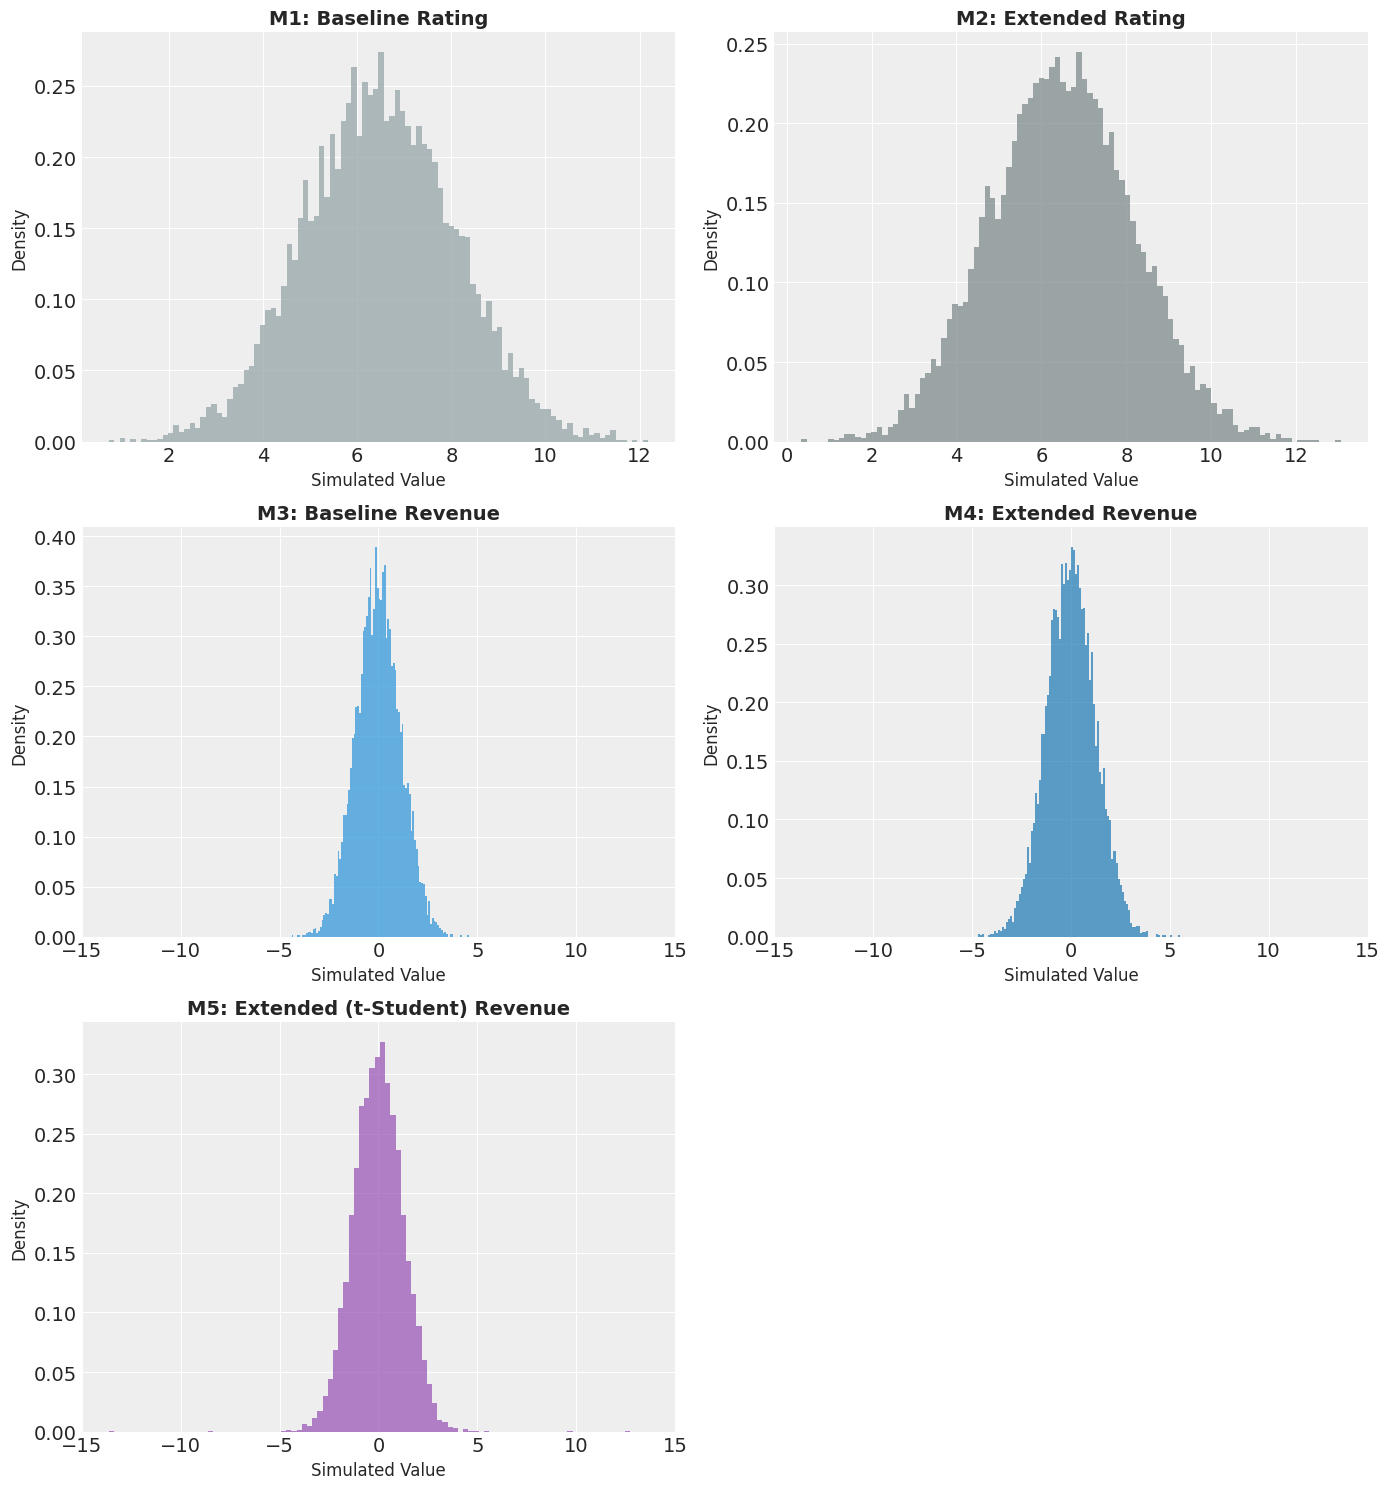

In [5]:
N_samples = 10000
num_movies = len(df_clean)

is_pg13 = df_clean['is_pg13'].values
is_dark = df_clean['is_dark_genre'].values
budget = df_clean['std_budget'].values
num_ratings = df_clean['Number of Ratings (in thousands)'].values

prior_plots = {'M1': [], 'M2': [], 'M3': [], 'M4': [], 'M5': []}

for _ in range(N_samples):
    # --- PRIORY DLA OCEN (RATING TRACK) ---
    alpha_r = np.random.normal(6.5, 1.5)
    b_dark_r = np.random.normal(0, 1)
    b_pg13_r = np.random.normal(0, 1)
    b_budget_r = np.random.normal(0, 1)
    b_pg13_dark_r = np.random.normal(0, 1)
    b_pg13_budget_r = np.random.normal(0, 1)
    b_dark_budget_r = np.random.normal(0, 1)
    b_triple_r = np.random.normal(0, 1)
    sigma_r = np.random.exponential(1)
    
    # NOWOŚĆ: Obliczamy zwagowane odchylenie standardowe dla każdego filmu osobno
    # Dodajemy 0.001, aby zabezpieczyć się przed dzieleniem przez zero
    weighted_sigma_r = sigma_r / np.sqrt(num_ratings + 0.001)
    
    # --- PRIORY DLA PRZYCHODÓW (REVENUE TRACK) ---
    alpha_v = np.random.normal(0, 1)
    b_dark_v = np.random.normal(0, 1)
    b_pg13_v = np.random.normal(0, 1)
    
    # MODYFIKACJA: Silny, dodatni prior dla budżetu odzwierciedlający intuicję ekonomiczną
    b_budget_v = np.random.normal(0.7, 0.2) 
    
    b_pg13_dark_v = np.random.normal(0, 1)
    b_pg13_budget_v = np.random.normal(0, 1)
    b_dark_budget_v = np.random.normal(0, 1)
    b_triple_v = np.random.normal(0, 1)
    sigma_v = np.random.exponential(1)
    nu_v = np.random.gamma(2, 1/0.1)
    
    # ----------------------------------------------------
    # SYMULACJE MODELI (Z ZASTOSOWANIEM WAG DLA OCEN M1 I M2)
    # ----------------------------------------------------
    
    # M1: Baseline Rating (Z wagami)
    mu_m1 = alpha_r + b_dark_r * is_dark + b_budget_r * budget
    # Przekazujemy wektor indywidualnych odchyleń standardowych do np.random.normal
    y_m1 = np.random.normal(mu_m1, weighted_sigma_r)
    prior_plots['M1'].append(np.mean(y_m1))
    
    # M2: Extended Rating (Z wagami)
    mu_m2 = (alpha_r + b_pg13_r * is_pg13 + b_dark_r * is_dark + b_budget_r * budget +
             b_pg13_dark_r * (is_pg13 * is_dark) +
             b_pg13_budget_r * (is_pg13 * budget) +
             b_dark_budget_r * (is_dark * budget) +
             b_triple_r * (is_pg13 * is_dark * budget))
    y_m2 = np.random.normal(mu_m2, weighted_sigma_r)
    prior_plots['M2'].append(np.mean(y_m2))
    
    # M3: Baseline Revenue (Zostaje klasyczny, bo przychody nie zależą od liczby ocen na IMDb)
    mu_m3 = alpha_v + b_dark_v * is_dark + b_budget_v * budget
    y_m3 = np.random.normal(mu_m3, sigma_v)
    prior_plots['M3'].append(np.mean(y_m3))
    
    # M4: Extended Revenue (Gauss)
    mu_m4 = (alpha_v + b_pg13_v * is_pg13 + b_dark_v * is_dark + b_budget_v * budget +
             b_pg13_dark_v * (is_pg13 * is_dark) +
             b_pg13_budget_v * (is_pg13 * budget) +
             b_dark_budget_v * (is_dark * budget) +
             b_triple_v * (is_pg13 * is_dark * budget))
    y_m4 = np.random.normal(mu_m4, sigma_v)
    prior_plots['M4'].append(np.mean(y_m4))
    
    # M5: Extended Revenue (Student-t)
    y_m5 = mu_m4 + np.random.standard_t(nu_v, size=num_movies) * sigma_v
    prior_plots['M5'].append(np.mean(y_m5))

for key in prior_plots:
    prior_plots[key] = np.array(prior_plots[key])


fig, axes = plt.subplots(3, 2, figsize=(14, 15))
az.style.use('arviz-darkgrid')

titles = [
    "M1: Baseline Rating", "M2: Extended Rating",
    "M3: Baseline Revenue", "M4: Extended Revenue",
    "M5: Extended (t-Student) Revenue"
]
keys = ['M1', 'M2', 'M3', 'M4', 'M5']
colors = ['#95a5a6', '#7f8c8d', '#3498db', '#2980b9', '#9b59b6']

for i, ax in enumerate(axes.flat[:5]):
    current_data = prior_plots[keys[i]]
    
    # Filter outliers for the t-Student model (M5) to improve visualization (since t-Student can produce extreme values)
    if keys[i] == 'M5':
        current_data = current_data[(current_data > -15) & (current_data < 15)]
        
    ax.hist(current_data, bins=100, color=colors[i], density=True, alpha=0.75, edgecolor='none')
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel("Simulated Value", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    
    if keys[i] in ['M3', 'M4', 'M5']:
        ax.set_xlim(-15, 15)

axes.flat[-1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_29107/1924388738.py:33: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


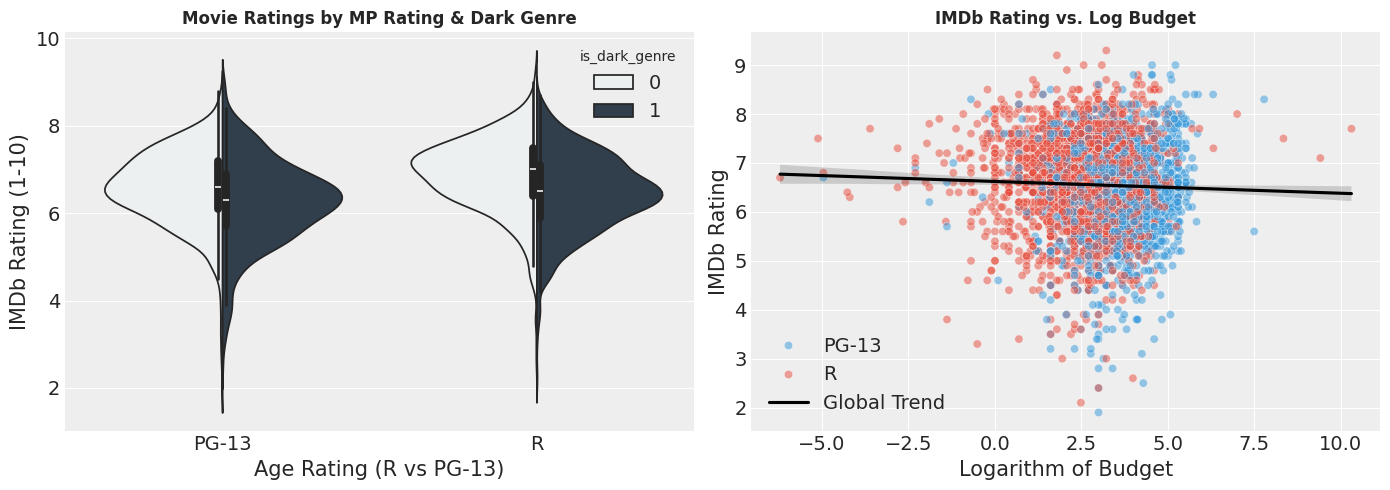

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=df_clean, 
    x='Motion Picture Rating', 
    y='Rating (Out of 10)', 
    hue='is_dark_genre',
    split=True,
    palette={1: '#2c3e50', 0: '#ecf0f1'},
    ax=axes[0]
)
axes[0].set_title("Movie Ratings by MP Rating & Dark Genre", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Age Rating (R vs PG-13)")
axes[0].set_ylabel("IMDb Rating (1-10)")

# 2. Korelacja budżetu z oceną
sns.scatterplot(
    data=df_clean, 
    x='log_budget', 
    y='Rating (Out of 10)', 
    hue='Motion Picture Rating',
    alpha=0.5,
    palette={'R': '#e74c3c', 'PG-13': '#3498db'},
    ax=axes[1]
)
# Dodanie linii trendu, żeby zobaczyć czy relacja w ogóle istnieje
sns.regplot(data=df_clean, x='log_budget', y='Rating (Out of 10)', scatter=False, ax=axes[1], color='black', label='Global Trend')
axes[1].set_title("IMDb Rating vs. Log Budget", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Logarithm of Budget")
axes[1].set_ylabel("IMDb Rating")
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_29107/1495129780.py:15: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


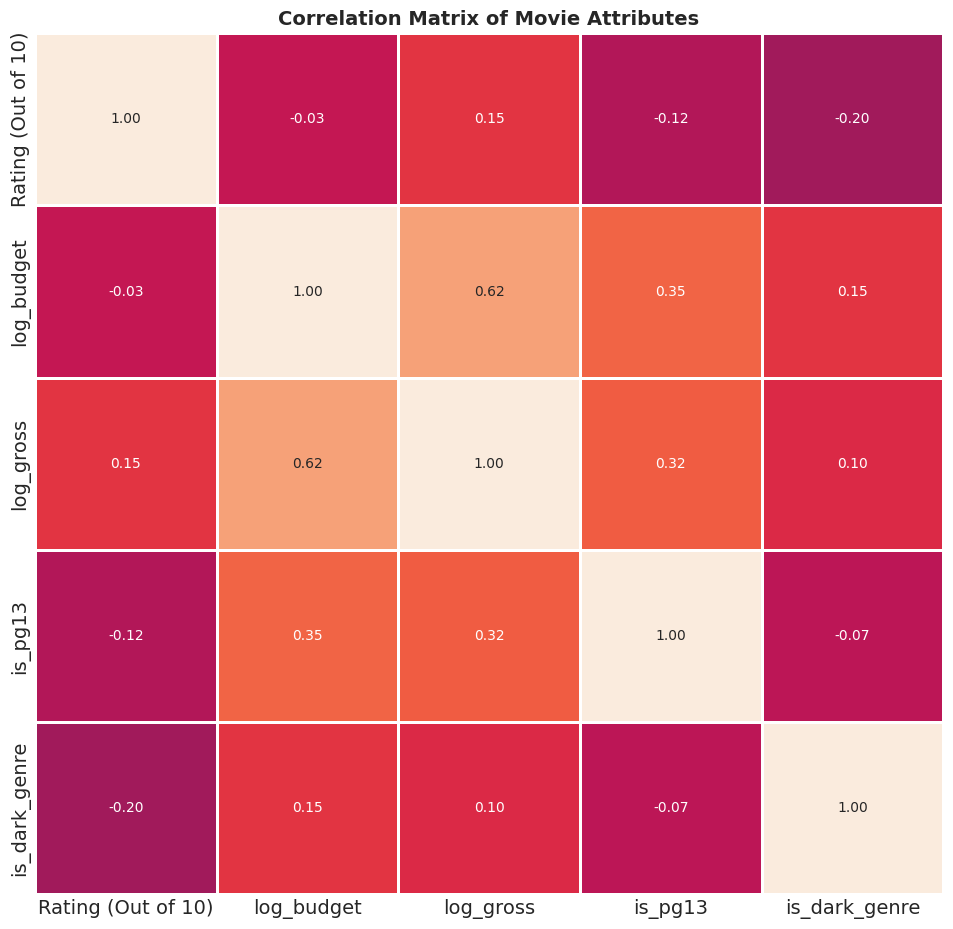

In [7]:
plt.figure(figsize=(12, 12))

# Wybieramy kluczowe kolumny do korelacji
corr_matrix = df_clean[['Rating (Out of 10)', 'log_budget', 'log_gross', 'is_pg13', 'is_dark_genre']].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    linewidths=.8,
    vmin=-1, vmax=1,
    cbar=False
)
plt.title("Correlation Matrix of Movie Attributes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  self._figure.tight_layout(*args, **kwargs)


<Figure size 900x600 with 0 Axes>

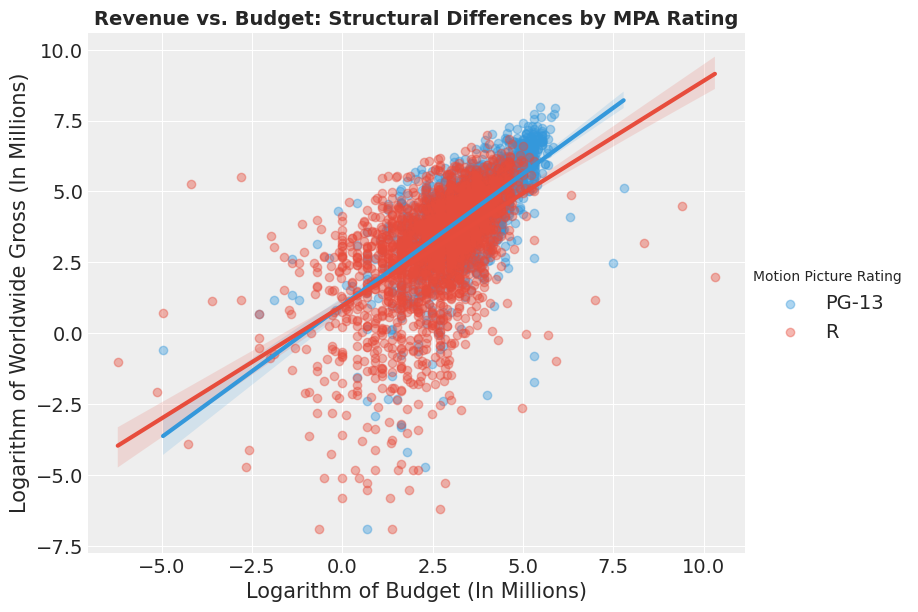

In [8]:
plt.figure(figsize=(9, 6))

# Rysujemy punkty i osobne linie trendu OLS dla każdej kategorii wiekowej
sns.lmplot(
    data=df_clean, 
    x='log_budget', 
    y='log_gross', 
    hue='Motion Picture Rating',
    palette={'R': '#e74c3c', 'PG-13': '#3498db'},
    scatter_kws={'alpha': 0.4},
    line_kws={'lw': 3},
    height=6, 
    aspect=1.3
)

plt.title("Revenue vs. Budget: Structural Differences by MPA Rating", fontsize=14, fontweight='bold')
plt.xlabel("Logarithm of Budget (In Millions)")
plt.ylabel("Logarithm of Worldwide Gross (In Millions)")
plt.show()

In [9]:
model1_baseline_rating = CmdStanModel(stan_file='stan/model1_baseline_rating.stan')
model1_extended_rating = CmdStanModel(stan_file='stan/model1_extended_rating.stan')
model_student_rating = CmdStanModel(stan_file='stan/model_student_rating.stan')

model1_baseline_revenue = CmdStanModel(stan_file='stan/model1_baseline_revenue.stan')
model1_extended_revenue = CmdStanModel(stan_file='stan/model1_extended_revenue.stan')
model2_extended_revenue = CmdStanModel(
    stan_file='stan/model_student.stan',
)


INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:found newer exe file, not recompiling


## Rating analysis

#### Fit models

In [10]:
fit_model1_baseline_rating = model1_baseline_rating.sample(data=rating_data_baseline, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model1_extended_rating = model1_extended_rating.sample(data=rating_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model_student_rating = model_student_rating.sample(data=rating_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status



chain 1 |▉         | 00:00 Iteration:    1 / 2000 [  0%]  (Warmup)

chain 1 |█▎        | 00:01 Iteration:  100 / 2000 [  5%]  (Warmup)




chain 1 |█▊        | 00:02 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:02 Iteration:  300 / 2000 [ 15%]  (Warmup)



chain 1 |██▋       | 00:03 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:03 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:04 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 00:04 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:05 Iteration:  800 / 2000 [ 40%]  (Warmup)



chain 1 |█████     | 00:05 Iteration:  900 / 2000 [ 45%]  (Warmup)

chain 1 |█████▉    | 00:07 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:08 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:10 Iteration: 1200 / 2000 [ 60


INFO:cmdstanpy:CmdStan done processing.


INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status




chain 1 |▉         | 00:02 Iteration:    1 / 2000 [  0%]  (Warmup)



chain 1 |█▎        | 00:07 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 00:11 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:14 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:18 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:20 Iteration:  500 / 2000 [ 25%]  (Warmup)
chain 1 |███▋      | 00:23 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 00:25 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:28 Iteration:  800 / 2000 [ 40%]  (Warmup)



chain 1 |█████     | 00:32 Iteration:  900 / 2000 [ 45%]  (Warmup)




chain 1 |█████▉    | 00:35 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:38 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:42 Iteration: 1200 / 2000 [ 6


INFO:cmdstanpy:CmdStan done processing.


INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status


chain 1 |▉         | 00:05 Iteration:    1 / 2000 [  0%]  (Warmup)



chain 1 |█▎        | 00:08 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 00:11 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:13 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:16 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:19 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:21 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 00:25 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:27 Iteration:  800 / 2000 [ 40%]  (Warmup)


chain 1 |█████     | 00:31 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:35 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:40 Iteration: 1100 / 2000 [ 55%]  (Sampling)





chain 1 |██████▊   | 00:47 Iteration: 1200 / 2000 [ 6


INFO:cmdstanpy:CmdStan done processing.


#### Compare with `az`

In [11]:
idata_model1_baseline_rating = az.from_cmdstanpy(fit_model1_baseline_rating)
idata_model1_extended_rating = az.from_cmdstanpy(fit_model1_extended_rating)
idata_model_student_rating = az.from_cmdstanpy(fit_model_student_rating)

                             rank          loo      p_loo       d_loo  \
Student model                   0 -5782.652630  18.076548    0.000000   
Extended model (With PG-13)     1 -6411.592154  32.647925  628.939524   
Base Model (Without PG-13)      2 -6496.514823  20.228672  713.862194   

                               weight         se        dse  warning loo_scale  
Student model                0.805474  62.072616   0.000000    False       log  
Extended model (With PG-13)  0.125993  95.242279  72.264816    False       log  
Base Model (Without PG-13)   0.068533  95.815434  72.855232    False       log  


<AxesSubplot:xlabel='Log'>

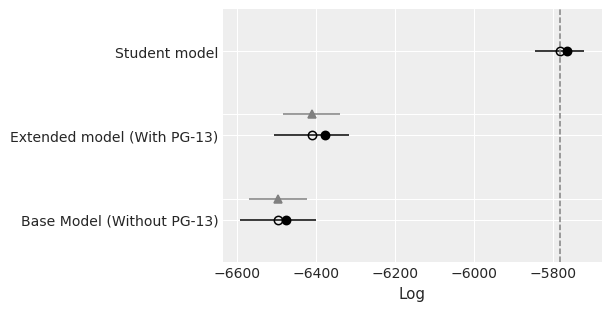

In [12]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_rating, "Extended model (With PG-13)": idata_model1_extended_rating, "Student model": idata_model_student_rating}, ic="loo")
print(comp)

az.plot_compare(comp)

#### Analyze

array([<AxesSubplot:title={'center':'94.0% HDI'}>], dtype=object)

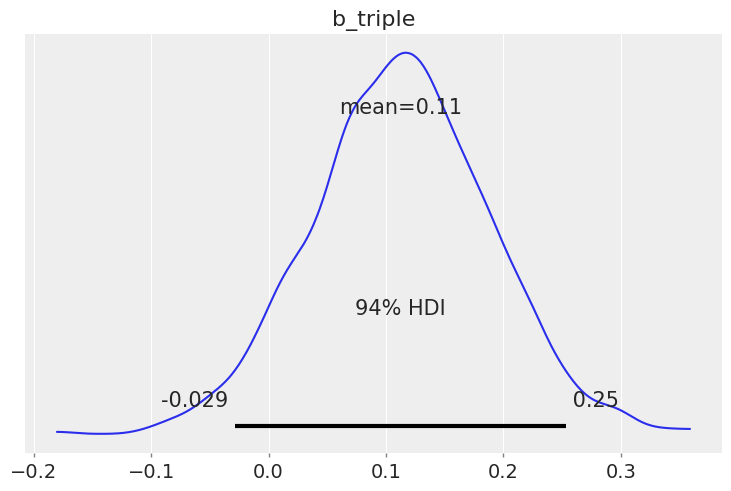

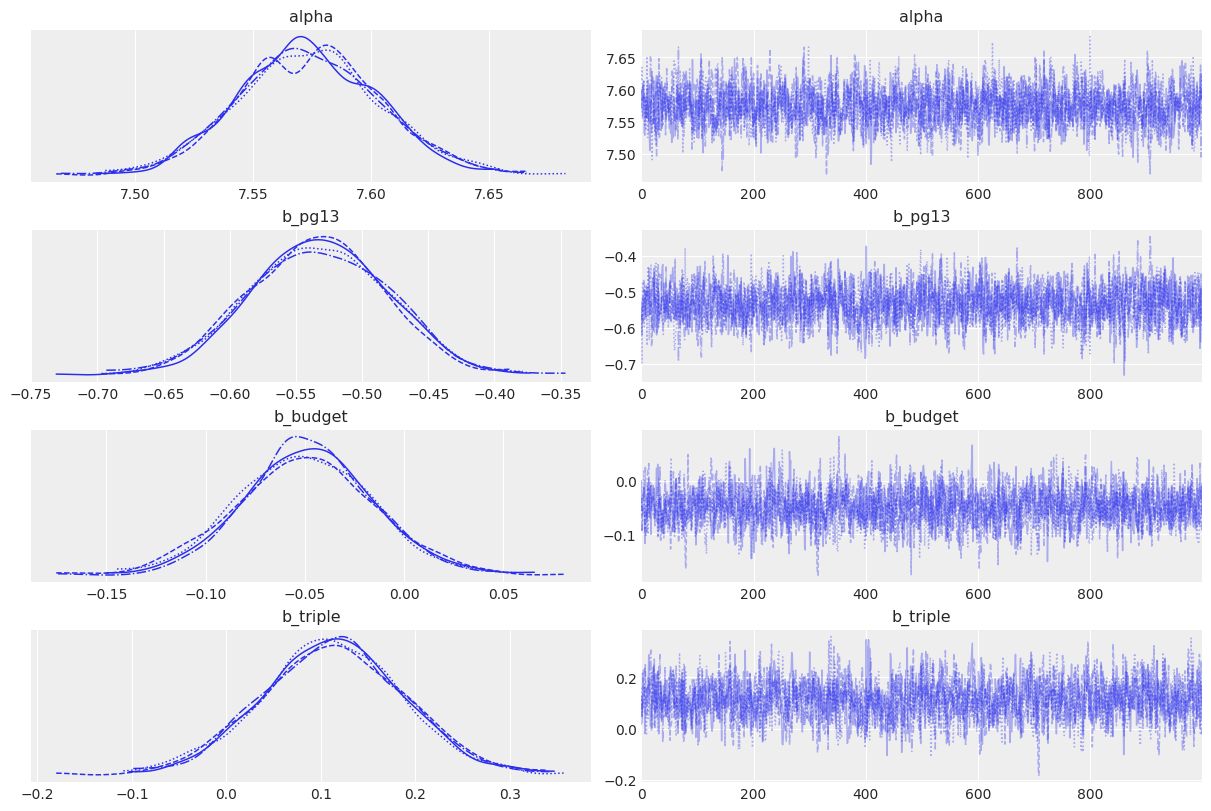

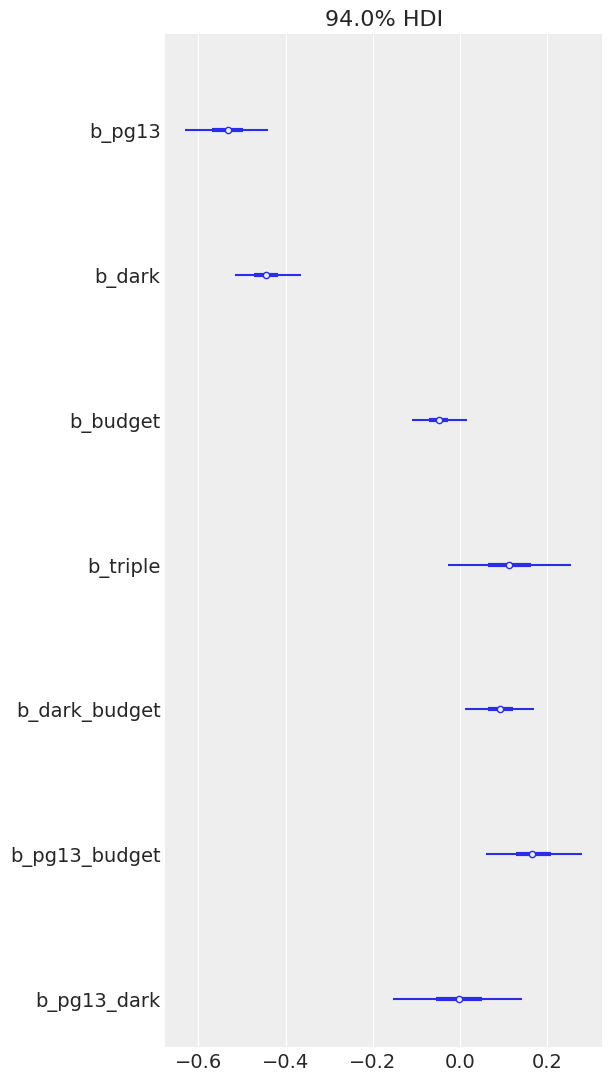

In [ ]:
az.plot_posterior(idata_model1_extended_rating, var_names=['b_triple'])
az.plot_trace(idata_model1_extended_rating, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model1_extended_rating, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

array([<AxesSubplot:title={'center':'94.0% HDI'}>], dtype=object)

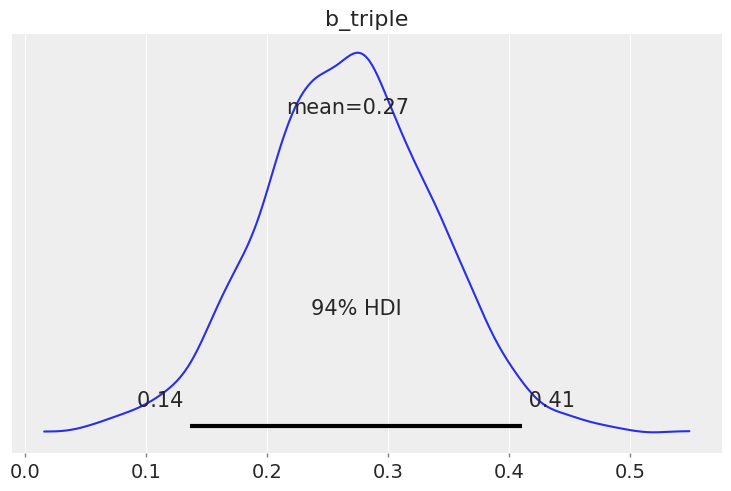

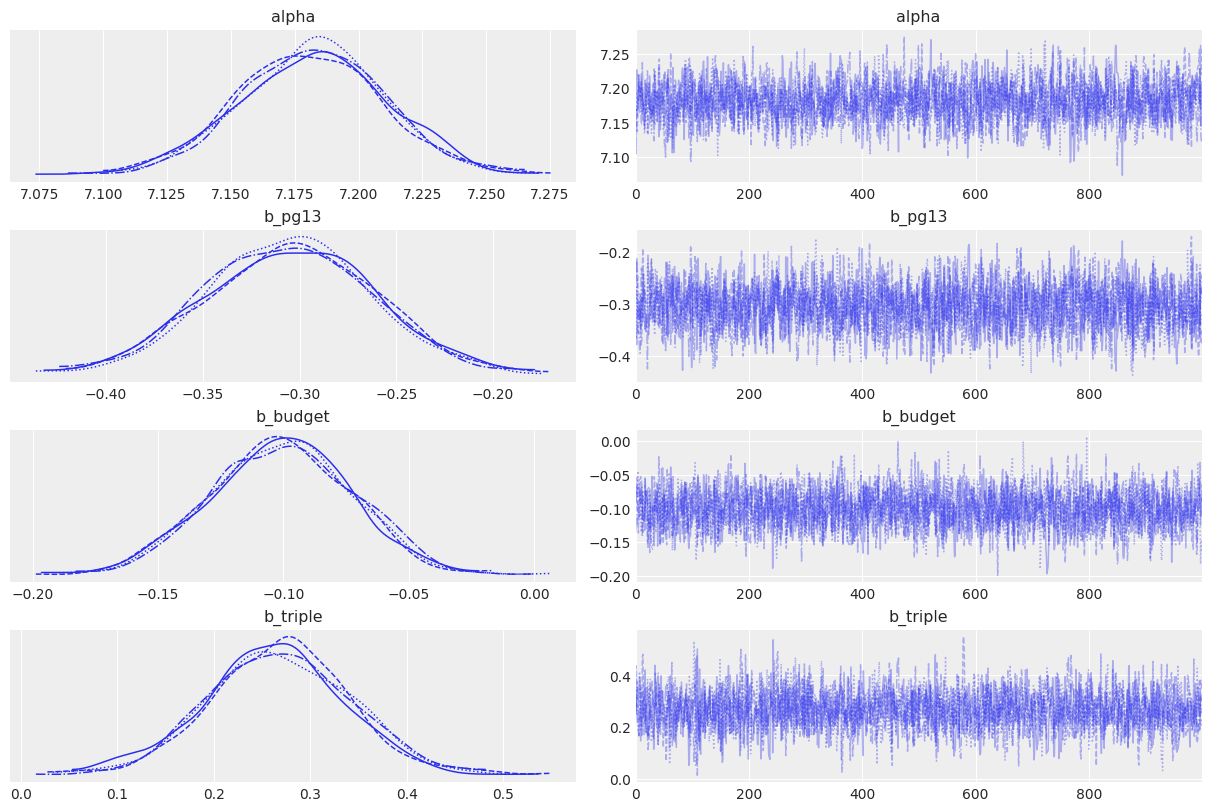

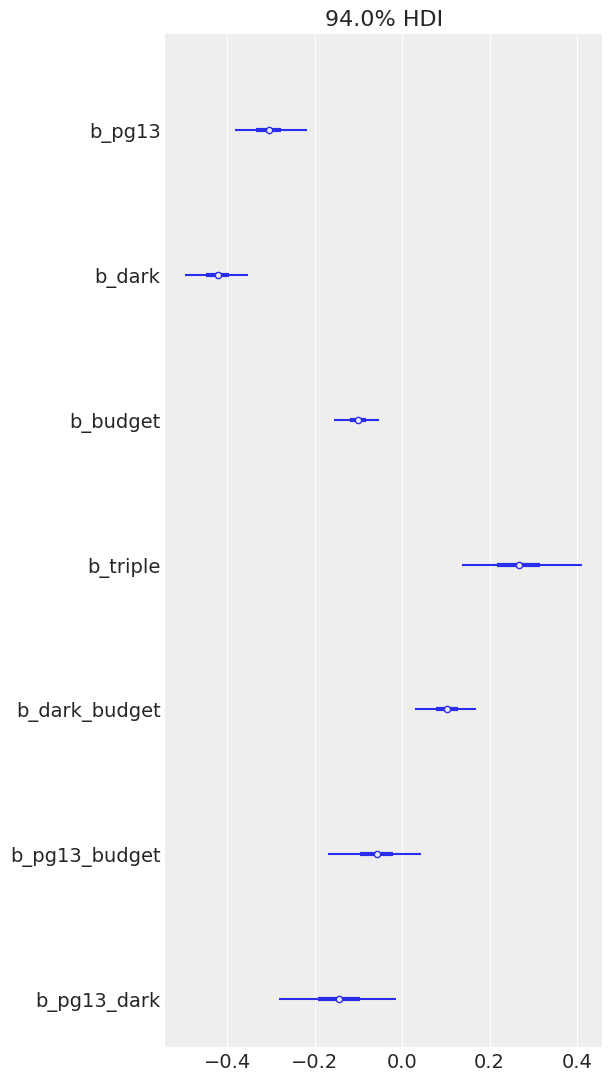

In [17]:
az.plot_posterior(idata_model_student_rating, var_names=['b_triple'])
az.plot_trace(idata_model_student_rating, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model_student_rating, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

#### Posterior predictive distribution

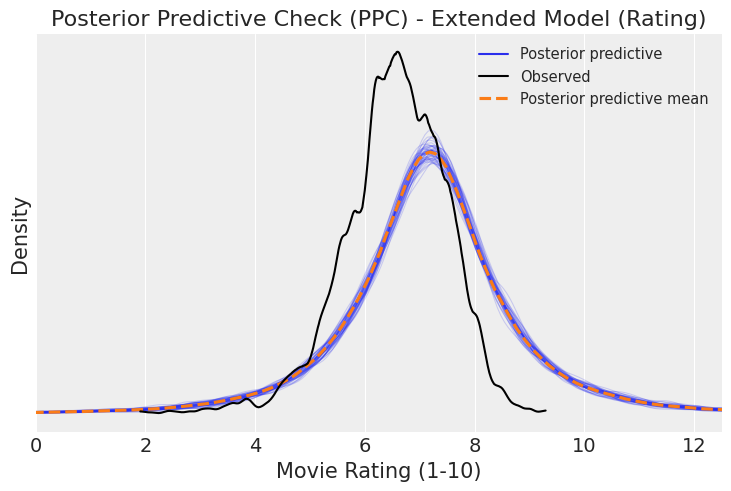

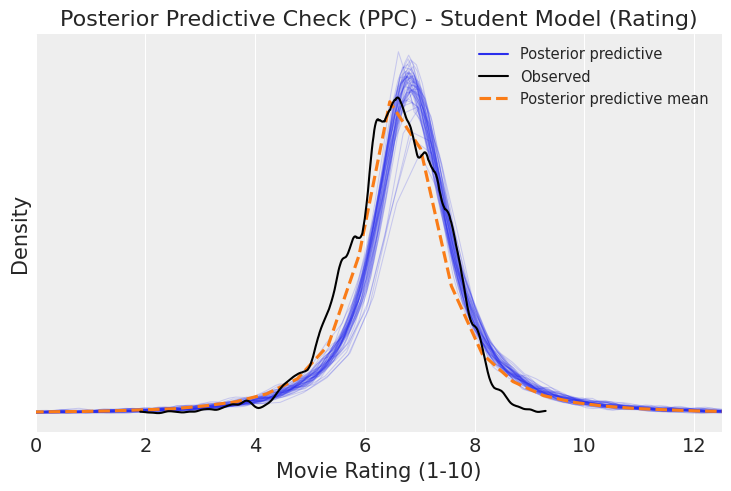

In [19]:

idata_extended_rating = az.from_cmdstanpy(
    posterior=fit_model1_extended_rating,
    posterior_predictive="y_rep",
observed_data={"y": df_clean["Rating (Out of 10)"].values})

az.plot_ppc(idata_extended_rating, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")
plt.xlim(0, 12.5)
plt.title("Posterior Predictive Check (PPC) - Extended Model (Rating)")
plt.xlabel("Movie Rating (1-10)")
plt.ylabel("Density")
plt.show()


idata_student_rating = az.from_cmdstanpy(
    posterior=fit_model_student_rating,
    posterior_predictive="y_rep",
observed_data={"y": df_clean["Rating (Out of 10)"].values})

az.plot_ppc(idata_student_rating, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")
plt.xlim(0, 12.5)
plt.title("Posterior Predictive Check (PPC) - Student Model (Rating)")
plt.xlabel("Movie Rating (1-10)")
plt.ylabel("Density")
plt.show()

## Revenue analysis

#### Fit models

In [50]:
fit_model1_baseline_revenue = model1_baseline_revenue.sample(data=revenue_data_baseline, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model1_extended_revenue = model1_extended_revenue.sample(data=revenue_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status



chain 1 |▉         | 00:00 Iteration:    1 / 2000 [  0%]  (Warmup)

chain 1 |█▎        | 00:00 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:01 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:01 Iteration:  300 / 2000 [ 15%]  (Warmup)



chain 1 |██▋       | 00:02 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:02 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:02 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 00:02 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:03 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████     | 00:03 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:04 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:05 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:06 Iteration: 1200 / 2000 [ 60%]


INFO:cmdstanpy:CmdStan done processing.


INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status



chain 1 |▉         | 00:00 Iteration:    1 / 2000 [  0%]  (Warmup)

chain 1 |█▎        | 00:03 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:05 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:07 Iteration:  300 / 2000 [ 15%]  (Warmup)



chain 1 |██▋       | 00:09 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:11 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:13 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 00:14 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:16 Iteration:  800 / 2000 [ 40%]  (Warmup)


chain 1 |█████     | 00:17 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:19 Iteration: 1001 / 2000 [ 50%]  (Sampling)

chain 1 |██████▎   | 00:21 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:23 Iteration: 1200 / 2000 [ 60%]


INFO:cmdstanpy:CmdStan done processing.


#### Compare with `az`

In [51]:
idata_model1_baseline_revenue = az.from_cmdstanpy(fit_model1_baseline_revenue)
idata_model1_extended_revenue = az.from_cmdstanpy(fit_model1_extended_revenue)

                             rank          loo      p_loo     d_loo    weight  \
Extended model (With PG-13)     0 -4538.426582  15.126434   0.00000  0.980599   
Base Model (Without PG-13)      1 -4577.281492  10.438075  38.85491  0.019401   

                                    se       dse  warning loo_scale  
Extended model (With PG-13)  81.805898  0.000000    False       log  
Base Model (Without PG-13)   82.488973  9.449571    False       log  


<AxesSubplot:xlabel='Log'>

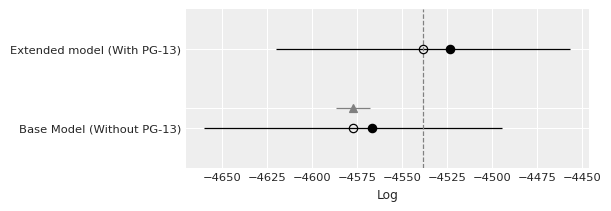

In [52]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (With PG-13)": idata_model1_extended_revenue}, ic="loo")
print(comp)

az.plot_compare(comp)

/usr/local/lib/python3.9/site-packages/arviz/stats/stats.py:1635: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


                             rank         waic     p_waic     d_waic  \
Extended model (With PG-13)     0 -4538.429814  15.129665   0.000000   
Base Model (Without PG-13)      1 -4577.275298  10.431881  38.845483   

                               weight         se       dse  warning waic_scale  
Extended model (With PG-13)  0.980522  81.806288  0.000000     True        log  
Base Model (Without PG-13)   0.019478  82.488075  9.448555     True        log  


/usr/local/lib/python3.9/site-packages/arviz/stats/stats.py:1635: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


<AxesSubplot:xlabel='Log'>

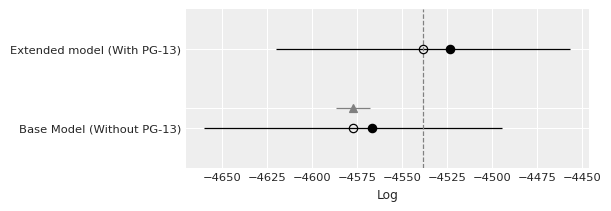

In [53]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (With PG-13)": idata_model1_extended_revenue}, ic="waic")
print(comp)

az.plot_compare(comp)

#### Analyze

array([<AxesSubplot:title={'center':'94.0% HDI'}>], dtype=object)

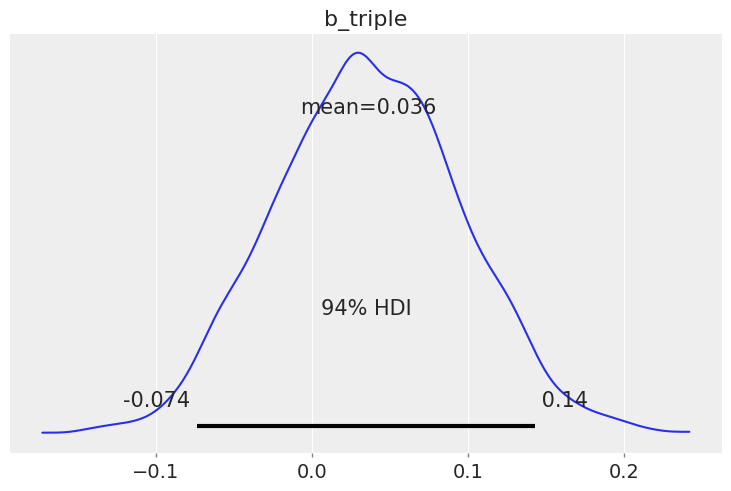

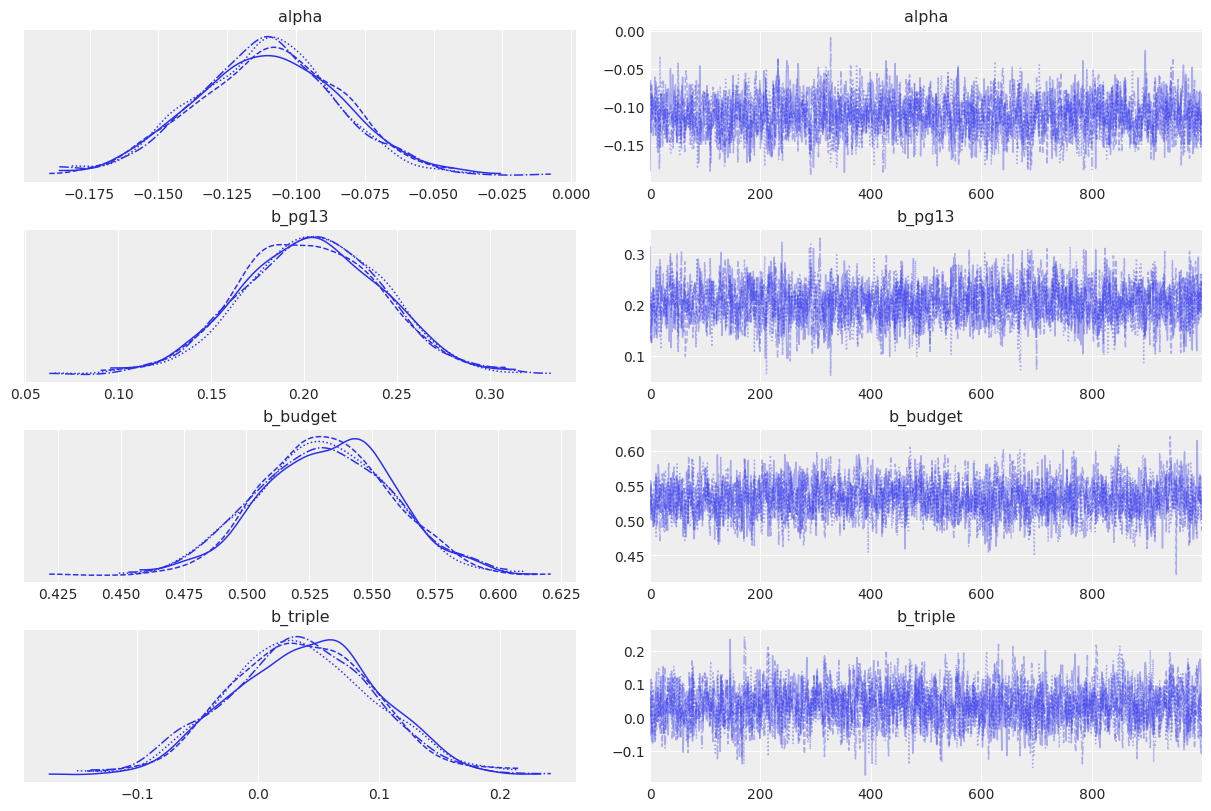

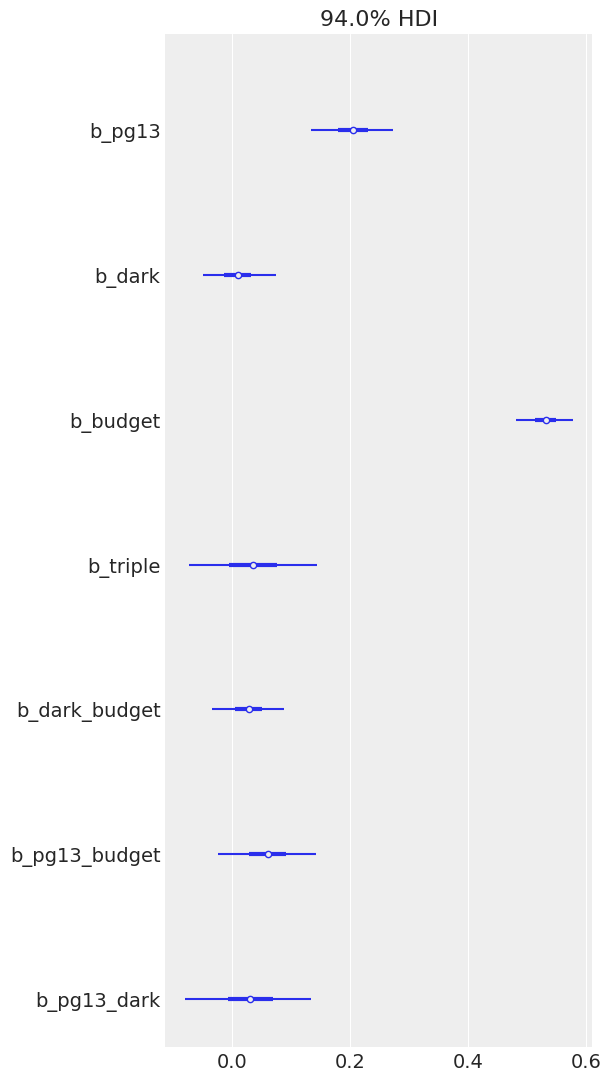

In [54]:
az.plot_posterior(idata_model1_extended_revenue, var_names=['b_triple'])
az.plot_trace(idata_model1_extended_revenue, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model1_extended_revenue, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

#### Posterior predictive distribution

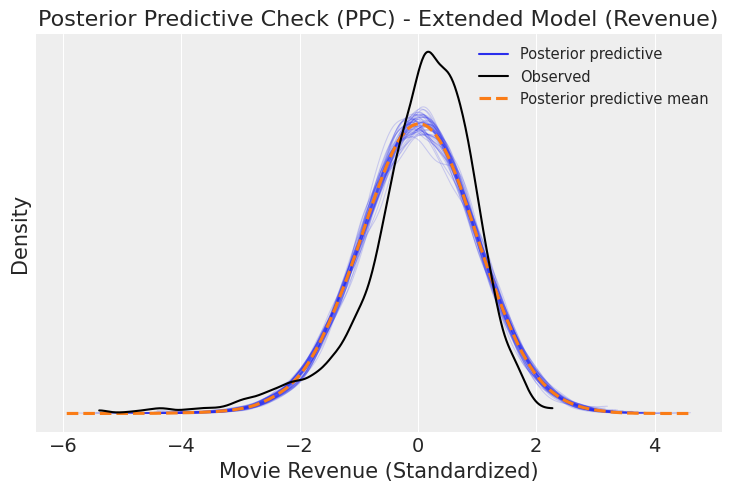

In [55]:
idata_extended_revenue = az.from_cmdstanpy(
    posterior=fit_model1_extended_revenue,
    posterior_predictive="y_rep",
    observed_data={"y": df_clean["std_gross"].values}
)

az.plot_ppc(idata_extended_revenue, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")

plt.title("Posterior Predictive Check (PPC) - Extended Model (Revenue)")
plt.xlabel("Movie Revenue (Standardized)")
plt.ylabel("Density")
plt.show()

## Model 2 (Student's T distribution)

In [56]:
fit_model2_extended_revenue = model2_extended_revenue.sample(data=revenue_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status





chain 1 |▉         | 00:03 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 00:06 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:10 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:13 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:16 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:18 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:19 Iteration:  600 / 2000 [ 30%]  (Warmup)



chain 1 |████      | 00:21 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 00:23 Iteration:  800 / 2000 [ 40%]  (Warmup)


chain 1 |█████     | 00:26 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |█████▉    | 00:28 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:30 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:34 Iteration: 1200 / 2000 [ 6


INFO:cmdstanpy:CmdStan done processing.


In [57]:
idata_model2_extended_revenue = az.from_cmdstanpy(fit_model2_extended_revenue)

                                         rank          loo      p_loo  \
Extended model (Student-t) (With PG-13)     0 -4142.624276  12.633057   
Base Model (Without PG-13)                  1 -4577.281492  10.438075   

                                              d_loo    weight         se  \
Extended model (Student-t) (With PG-13)    0.000000  0.953932  66.089634   
Base Model (Without PG-13)               434.657216  0.046068  82.488973   

                                              dse  warning loo_scale  
Extended model (Student-t) (With PG-13)   0.00000    False       log  
Base Model (Without PG-13)               43.30924    False       log  


<AxesSubplot:xlabel='Log'>

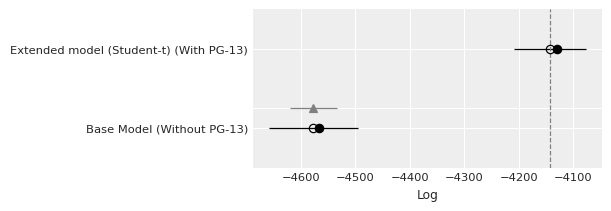

In [58]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (Student-t) (With PG-13)": idata_model2_extended_revenue}, ic="loo")
print(comp)

az.plot_compare(comp)

array([<AxesSubplot:title={'center':'94.0% HDI'}>], dtype=object)

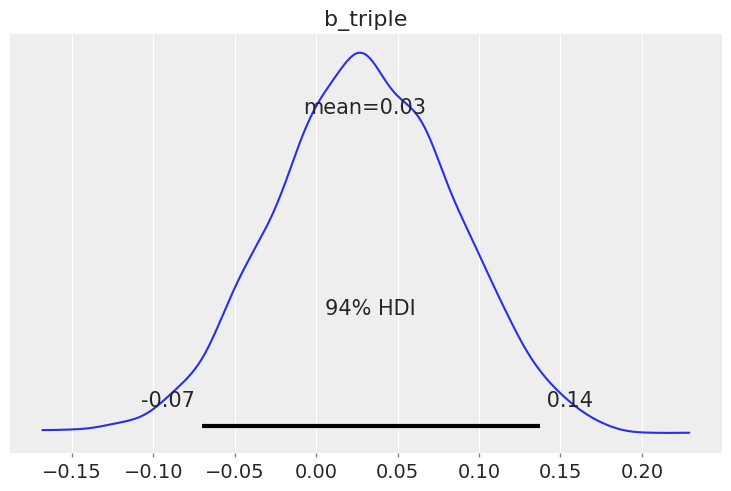

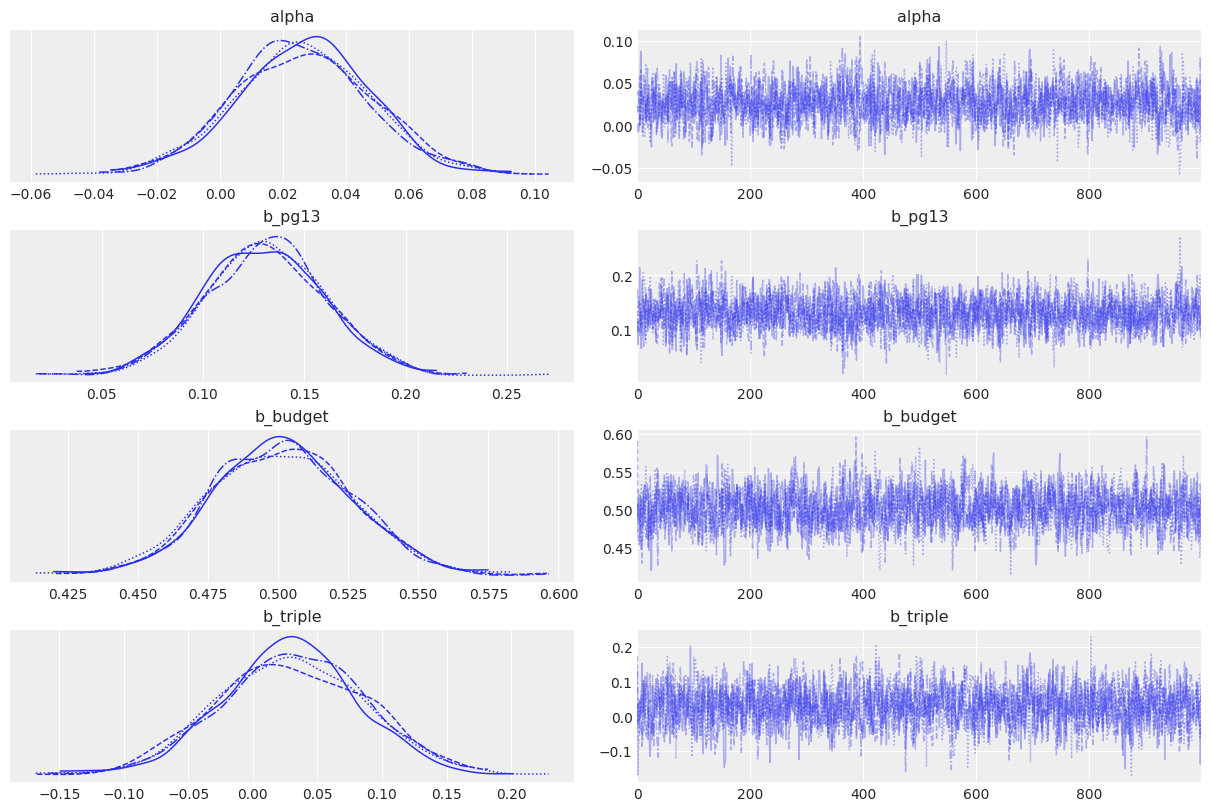

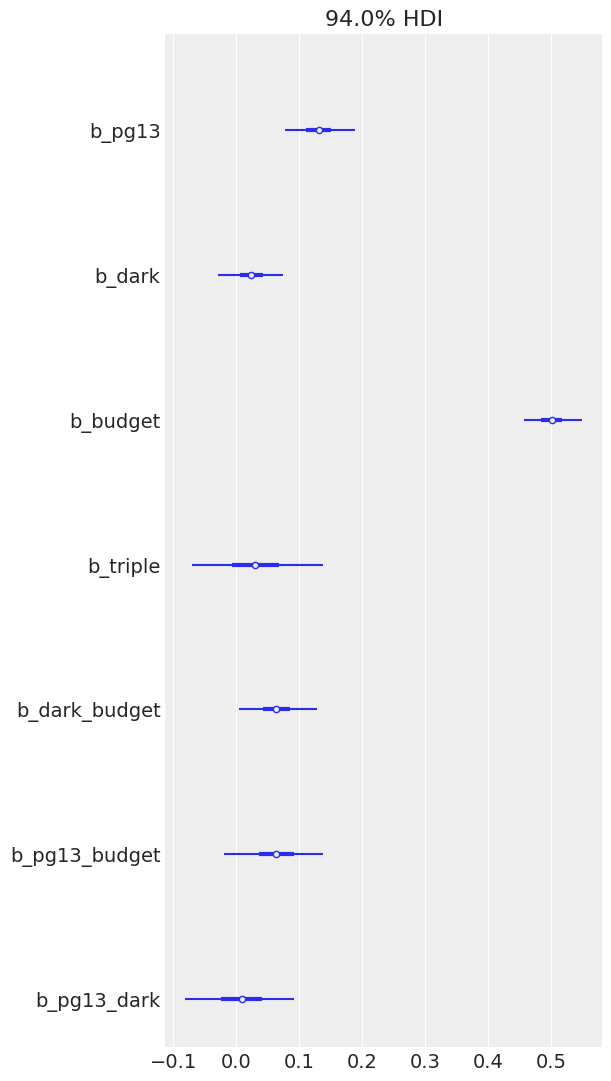

In [60]:
az.plot_posterior(idata_model2_extended_revenue, var_names=['b_triple'])
az.plot_trace(idata_model2_extended_revenue, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model2_extended_revenue, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

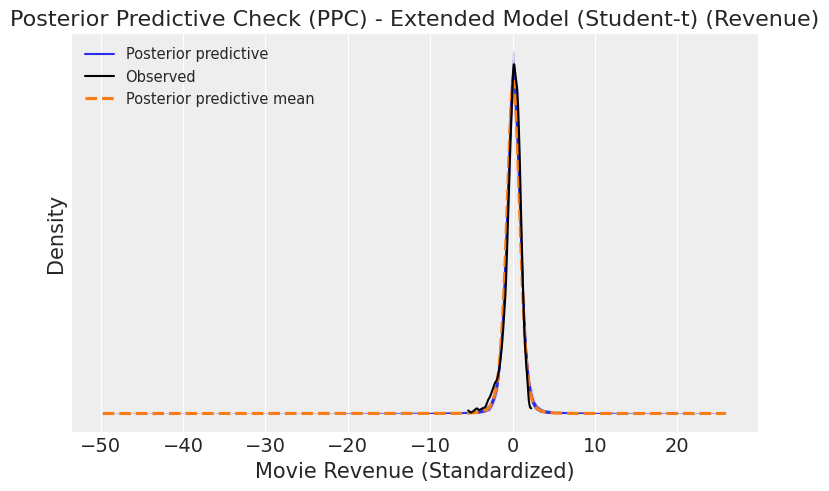

In [61]:
idata_model2_extended_revenue = az.from_cmdstanpy(
    posterior=fit_model2_extended_revenue,
    posterior_predictive="y_rep",
    observed_data={"y": df_clean["std_gross"].values}
)

az.plot_ppc(idata_model2_extended_revenue, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")

plt.title("Posterior Predictive Check (PPC) - Extended Model (Student-t) (Revenue)")
plt.xlabel("Movie Revenue (Standardized)")
plt.ylabel("Density")
plt.show()